# Practical Feature Engineering — missing values, encoding, scaling and geo features on real data

01 Core Python · 02 Pandas · 03 Cleaning · 04 Transformation · **▶ 05 Feature Engineering** · 06 Regression · 07 Model Prep · 08 Case Studies

`05_Feature_Engineering/06_practical_feature_engineering_case_study.ipynb`

---

### In one paragraph (no jargon)

Real datasets rarely arrive as one clean table with a handful of numeric columns. This case study works two genuinely messy, real-world datasets end to end: a Nigerian **loan default** dataset spread across three related tables (demographics, current-loan performance, and loan history), and a Kenyan **delivery-time** dataset (Sendy) with dense date/time and GPS columns. Between them they touch almost every feature-engineering technique in this course — missing-value imputation (simple and model-based), categorical encoding, numerical transforms, polynomial interactions, scaling, date/time extraction, and geo-distance features — so treat it as the capstone that ties `03_Data_Cleaning/`, `04_Data_Transformation/` and the rest of `05_Feature_Engineering/` together on data nobody has pre-cleaned for you.

### After this notebook you can

- Choose and justify a missing-value strategy per column — mode fill, mean/median fill, regression-based fill, or `IterativeImputer`
- Encode categorical features multiple ways (ordinal map, label/ordinal encoding, one-hot, hashing) and know when each is appropriate
- Engineer numerical features from domain knowledge (elapsed interest, per-customer aggregates, speed) without breaking the columns you engineered them from
- Build polynomial interaction features and compare Standard/Robust/MinMax scaling
- Extract calendar features and elapsed time from raw date strings, and derive Manhattan/Haversine distance and bearing from latitude/longitude pairs

### What's inside

1. Load & first look — four real, related datasets
2. Missing values — categorical features
3. Missing values — numerical features (mean/median/mode, regression fill, IterativeImputer)
4. Categorical features — manual ordinal maps & automated encoders
5. Numerical feature engineering — log transforms & domain-knowledge features
6. Polynomial (interaction) features
7. Normalization & scaling
8. Date/time feature extraction
9. Geo features from latitude & longitude

---

> **▶ Runs on its own.** The next cell is the only setup you need. It imports the
> libraries and loads the data. If the `datasets/` folder isn't where it expects,
> it rebuilds an equivalent dataset in memory so **every cell below still runs** —
> handy if you copy this single `.ipynb` somewhere else.
>
> **▶ Reading the cells.** Code comments explain *what the line does*; the text
> blocks explain *why you'd do it*. Look for these markers:
> `# WHAT:` a plain-English translation · `# WHY:` the reason it matters ·
> `# 🔧 CHANGE THIS:` the knob to turn when the exam question differs ·
> **⚡ Beyond the syllabus** = optional, higher-mark techniques.

### Jargon buster

| Term | Plain English |
|---|---|
| **Imputation** | Filling in a missing value with a calculated stand-in (mean, median, mode, or a model's prediction). |
| **Ordinal encoding** | Assigning each category an integer code — appropriate when categories have a natural order, or as a compact stand-in for "label encoding". |
| **One-hot encoding** | One binary column per category. Exact, but the column count grows with the number of categories. |
| **Hashing encoding** | Mapping categories into a small, fixed number of columns via a hash function. Trades a (rare) collision for a column count that never grows. |
| **Polynomial / interaction feature** | A new column built by multiplying (or otherwise combining) two or more existing columns, so a model can see combined effects it couldn't see from the raw columns alone. |
| **Scaling / normalization** | Rescaling numeric columns onto a common range so no single feature dominates a distance-based model just because its raw numbers are bigger. |
| **Haversine distance** | The great-circle (curved-earth) distance between two latitude/longitude points — more accurate over real-world distances than a flat Manhattan distance. |
| **Bearing** | The compass direction (0-360 deg) from one geographic point to another. |

In [1]:
# =============================================================================
# SETUP — run this cell first. It is the only cell with dependencies.
# =============================================================================
# WHAT: `import` pulls in code other people have written so we don't rewrite it.
#       The `as pd` part is a nickname, so we can type `pd` instead of `pandas`.
import pandas as pd          # tables of data (think: Excel, but programmable)
import numpy as np           # fast maths on whole columns at once
import matplotlib.pyplot as plt   # charts
import warnings

warnings.filterwarnings('ignore')          # hide version-upgrade notices, keeps output readable
pd.set_option('display.max_columns', 50)   # don't hide columns behind "..."
pd.set_option('display.width', 160)
import os
import seaborn as sns
sns.set_theme(style="whitegrid")

def _p(probs):
    """Normalise a hand-typed probability list so it sums to exactly 1.

    WHY: rounded real-world proportions (e.g. 0.3677 + ... + 0.0016) rarely sum
    to *exactly* 1.0, and numpy's Generator.choice rejects anything else.
    """
    probs = np.asarray(probs, dtype=float)
    return probs / probs.sum()

# ---------------------------------------------------------------------------
# `category_encoders` provides Ordinal, One-Hot and Hashing encoders. It is an
# optional library, so if it isn't installed we supply equivalents written in
# plain pandas below. Seeing the implementation is arguably more instructive
# than importing it — each is only a few lines.
# ---------------------------------------------------------------------------
try:
    import category_encoders as ce
    print("Using the category_encoders library.")
except ImportError:
    print("category_encoders not installed - using the built-in equivalents below.")

    class _OrdinalEncoder:
        """Assign each category an arbitrary integer code (a.k.a. label encoding)."""
        def __init__(self, cols=None, **kw):
            self.cols, self.maps_ = cols, {}

        def fit(self, X, y=None):
            X = pd.DataFrame(X).copy()
            for col in (self.cols or X.columns):
                self.maps_[col] = {v: i + 1 for i, v in enumerate(sorted(X[col].dropna().astype(str).unique()))}
            return self

        def transform(self, X):
            X = pd.DataFrame(X).copy()
            for col, mapping in self.maps_.items():
                X[col] = X[col].astype(str).map(mapping)
            return X

        def fit_transform(self, X, y=None):
            return self.fit(X, y).transform(X)

    class _OneHotEncoder:
        """One binary column per category (thin wrapper over pd.get_dummies)."""
        def __init__(self, cols=None, use_cat_names=False, **kw):
            self.cols, self.use_cat_names = cols, use_cat_names

        def fit(self, X, y=None):
            return self

        def transform(self, X):
            X = pd.DataFrame(X).copy()
            cols = self.cols or X.columns
            return pd.get_dummies(X, columns=list(cols), prefix=list(cols) if self.use_cat_names else None, dtype=int)

        def fit_transform(self, X, y=None):
            return self.fit(X, y).transform(X)

    class _HashingEncoder:
        """Hash each category into one of n fixed buckets.

        WHY: the output width is fixed in advance, however many categories appear -
        so an unseen category at prediction time can never break anything.
        COST: two categories can land in the same bucket (a 'collision').
        """
        def __init__(self, n_components=8, cols=None, **kw):
            self.n, self.cols = n_components, cols

        def fit(self, X, y=None):
            return self

        def transform(self, X):
            X = pd.DataFrame(X).copy()
            out = pd.DataFrame(0, index=X.index, columns=[f"col_{i}" for i in range(self.n)])
            for col in (self.cols or X.columns):
                for i, value in enumerate(X[col].astype(str)):
                    out.iloc[i, hash(value) % self.n] += 1
            return out

        def fit_transform(self, X, y=None):
            return self.fit(X, y).transform(X)

    class _CE:
        OrdinalEncoder = _OrdinalEncoder
        OneHotEncoder = _OneHotEncoder
        HashingEncoder = _HashingEncoder

    ce = _CE()

def find_datasets_folder(start=None):
    """Walk upwards from this notebook looking for the shared `datasets/` folder.

    WHY: it means the notebook works whether you opened it from its own folder,
    from the top of the notes, or from anywhere else on your machine.
    """
    here = os.path.abspath(start or os.getcwd())
    for _ in range(6):                       # look up to 6 folders up
        candidate = os.path.join(here, 'datasets')
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None

def dataset_path(filename, rebuild=None):
    """Return a real path to `filename`, materialising a temp copy if it's missing.

    WHY: a few pandas tools (pd.ExcelFile, pd.read_sql) need an actual file path
         rather than a DataFrame, so the fallback has to be written to disk.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            return path
    if rebuild is None:
        raise FileNotFoundError(filename)
    import tempfile
    tmp = os.path.join(tempfile.mkdtemp(prefix='bda_'), filename)
    frame = rebuild()
    (frame.to_excel(tmp, index=False) if filename.lower().endswith(('.xlsx', '.xls'))
     else frame.to_csv(tmp, index=False))
    print(f"'{filename}' not found -> wrote a rebuilt copy to {tmp}")
    return tmp

def load_data(filename, rebuild=None, **read_kwargs):
    """Load `filename` from the shared datasets folder, or rebuild it in memory.

    WHAT: tries to read the real file; if it can't find it, calls `rebuild()`
          which recreates a dataset with the same columns and behaviour.
    WHY:  guarantees this notebook runs even if the CSV goes missing.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            reader = pd.read_excel if filename.lower().endswith(('.xlsx', '.xls')) else pd.read_csv
            print(f"Loaded '{filename}' from {folder}")
            return reader(path, **read_kwargs)
    if rebuild is None:
        raise FileNotFoundError(f"Could not find {filename} and no fallback was supplied.")
    print(f"'{filename}' not found on disk -> rebuilding an equivalent dataset in memory.")
    built = rebuild()
    if 'chunksize' in read_kwargs:            # keep chunked reads working on the fallback path
        size = read_kwargs['chunksize']
        return (built.iloc[i:i + size] for i in range(0, len(built), size))
    return built

def _loan_customer_pool():
    """Deterministic customerid pools shared by the three loan-table rebuild
    functions below, so a fallback demographics/performance/previous trio still
    joins on customerid the way the real tables do (previous loans is a subset
    of performance's customers; demographics overlaps performance by about
    three-quarters).
    """
    rng = np.random.default_rng(7)
    def hex_id():
        return f"{rng.integers(0, 2**63):016x}{rng.integers(0, 2**63):016x}"
    performance_ids = np.array([hex_id() for _ in range(4368)])
    previous_ids = rng.choice(performance_ids, size=4359, replace=False)
    demographics_ids = np.concatenate([
        rng.choice(performance_ids, size=3277, replace=False),
        np.array([hex_id() for _ in range(4346 - 3277)]),
    ])
    rng.shuffle(demographics_ids)
    return performance_ids, previous_ids, demographics_ids

def rebuild_loan_demographics():
    """Rebuild a dataset statistically equivalent to loan_demographics.csv (4,346 rows).

    Same columns, same types, same ranges and category mix, so every cell
    below still runs if the original file is missing."""
    _, _, customerid = _loan_customer_pool()
    n = len(customerid)
    rng = np.random.default_rng(42)

    branches = ['OGBA', 'AJOSE ADEOGUN', 'OREGUN', 'APAPA', 'HEAD OFFICE', 'LAGOS', 'LADIPO',
                'AWOLOWO', 'ABULE EGBA', 'ABEOKUTA', 'TRANS AMADI', 'ALAUSA', 'OJUELEGBA',
                'MUSHIN BRANCH', 'AKUTE']
    frame = pd.DataFrame({
        'customerid': customerid,
        'birthdate': pd.to_datetime(rng.integers(
            int(pd.Timestamp('1961-10-13').value), int(pd.Timestamp('1996-03-28').value), n
        )),
        'bank_account_type': rng.choice(['Savings', 'Other', 'Current'], n, p=_p([0.7881, 0.1990, 0.0129])),
        'longitude_gps': rng.normal(4.63, 7.18, n).clip(-118.247009, 151.209290),
        'latitude_gps': rng.normal(7.25, 3.06, n).clip(-33.868818, 71.228069),
        'bank_name_clients': rng.choice(
            ['GT Bank', 'First Bank', 'Access Bank', 'UBA', 'Zenith Bank', 'Diamond Bank',
             'EcoBank', 'Stanbic IBTC', 'FCMB', 'Fidelity Bank', 'Skye Bank', 'Sterling Bank',
             'Wema Bank', 'Union Bank', 'Heritage Bank', 'Keystone Bank', 'Standard Chartered', 'Unity Bank'],
            n, p=_p([0.3677, 0.1358, 0.0994, 0.0812, 0.0693, 0.0649, 0.0345, 0.0334, 0.0278,
                     0.0237, 0.0235, 0.0127, 0.0064, 0.0053, 0.0051, 0.0044, 0.0035, 0.0016])),
        'bank_branch_clients': rng.choice(branches, n),
        'employment_status_clients': rng.choice(
            ['Permanent', 'Self-Employed', 'Student', 'Unemployed', 'Retired', 'Contract'],
            n, p=_p([0.8507, 0.0941, 0.0384, 0.0154, 0.0011, 0.0003])),
        'level_of_education_clients': rng.choice(
            ['Graduate', 'Secondary', 'Post-Graduate', 'Primary'], n, p=_p([0.7155, 0.1516, 0.1158, 0.0170])),
    })
    # Real missingness: bank_branch (98.8%), employment_status (14.9%), education (86.5%).
    frame.loc[rng.choice(n, int(n * 0.9883), replace=False), 'bank_branch_clients'] = np.nan
    frame.loc[rng.choice(n, int(n * 0.1491), replace=False), 'employment_status_clients'] = np.nan
    frame.loc[rng.choice(n, int(n * 0.8649), replace=False), 'level_of_education_clients'] = np.nan
    return frame

def rebuild_loan_performance():
    """Rebuild a dataset statistically equivalent to loan_performance.csv (4,368 rows).

    Same columns, same types, same ranges and category mix, so every cell
    below still runs if the original file is missing."""
    customerid, _, _ = _loan_customer_pool()
    n = len(customerid)
    rng = np.random.default_rng(43)

    loanamount = rng.choice(
        [10000., 15000., 20000., 25000., 30000., 35000., 40000., 45000., 50000., 60000.],
        n, p=_p([0.5636, 0.0188, 0.1786, 0.0071, 0.1337, 0.0023, 0.0762, 0.0002, 0.0176, 0.0018]))
    markup = rng.normal(1.2177, 0.0771, n).clip(1.0, 1.3)
    creationdate = pd.to_datetime(rng.integers(
        int(pd.Timestamp('2017-07-01').value), int(pd.Timestamp('2017-07-30').value), n
    ))
    approveddate = creationdate + pd.to_timedelta(rng.normal(64.1, 62.8, n).clip(60, 2316), unit='m')
    referredby = np.where(
        rng.random(n) < 0.1344,
        [f"{rng.integers(0, 2**63):016x}{rng.integers(0, 2**63):016x}" for _ in range(n)],
        None,
    )

    frame = pd.DataFrame({
        'customerid': customerid,
        'systemloanid': rng.integers(301958485, 302004050, n),
        'loannumber': rng.normal(5.17, 3.65, n).clip(2, 27).round().astype(int),
        'approveddate': approveddate,
        'creationdate': creationdate,
        'loanamount': loanamount,
        'totaldue': (loanamount * markup).round(2),
        'termdays': rng.choice([30, 15, 60, 90], n, p=_p([0.7163, 0.2104, 0.0659, 0.0073])),
        'referredby': referredby,
        'good_bad_flag': rng.choice(['Good', 'Bad'], n, p=_p([0.7821, 0.2179])),
    })
    return frame

def rebuild_loan_previous():
    """Rebuild a dataset statistically equivalent to loan_previous.csv (~18,183 rows
    across 4,359 customers, averaging ~4.2 previous loans each).

    Same columns, same types, same ranges and category mix, so every cell
    below still runs if the original file is missing."""
    _, customer_pool, _ = _loan_customer_pool()
    rng = np.random.default_rng(44)

    loans_per_customer = rng.normal(4.17, 3.65, len(customer_pool)).clip(1, 26).round().astype(int)
    customerid = np.repeat(customer_pool, loans_per_customer)
    n = len(customerid)

    loanamount = rng.choice(
        [10000., 20000., 30000., 40000., 15000., 50000., 25000., 5000., 8000., 35000.,
         6000., 7000., 9000., 4000., 3000.],
        n, p=_p([0.5792, 0.1939, 0.1349, 0.0477, 0.0217, 0.0058, 0.0055, 0.0052, 0.0021, 0.0015,
                 0.001, 0.0006, 0.0005, 0.0003, 0.0001]))
    markup = rng.normal(1.2037, 0.0743, n).clip(1.0, 1.3)
    termdays = rng.choice([30, 15, 60, 90], n, p=_p([0.6074, 0.3363, 0.0546, 0.0016]))

    creationdate = pd.to_datetime(rng.integers(
        int(pd.Timestamp('2016-01-15').value), int(pd.Timestamp('2017-07-28').value), n
    ))
    approveddate = creationdate + pd.to_timedelta(rng.normal(64.1, 62.8, n).clip(60, 2316), unit='m')
    closeddate = approveddate + pd.to_timedelta(rng.normal(23.9, 13.3, n).clip(0.01, 380.9), unit='D')
    firstduedate = approveddate + pd.to_timedelta(rng.normal(25.0, 7.2, n).clip(14.0, 34.5), unit='D')
    firstrepaiddate = firstduedate - pd.to_timedelta(rng.normal(2, 3, n).clip(-10, 15), unit='D')
    referredby = np.where(
        rng.random(n) < 0.0564,
        [f"{rng.integers(0, 2**63):016x}{rng.integers(0, 2**63):016x}" for _ in range(n)],
        None,
    )

    frame = pd.DataFrame({
        'customerid': customerid,
        'systemloanid': rng.integers(301600134, 302000275, n),
        'loannumber': rng.normal(4.19, 3.25, n).clip(1, 26).round().astype(int),
        'approveddate': approveddate,
        'creationdate': creationdate,
        'loanamount': loanamount,
        'totaldue': (loanamount * markup).round(2),
        'termdays': termdays,
        'closeddate': closeddate,
        'referredby': referredby,
        'firstduedate': firstduedate,
        'firstrepaiddate': firstrepaiddate,
    })
    return frame

def rebuild_sendy_logistics():
    """Rebuild a dataset statistically equivalent to sendy_logistics.csv (21,201 rows).

    Same columns, same types, same ranges and category mix, so every cell
    below still runs if the original file is missing."""
    rng = np.random.default_rng(42)
    n = 21201

    order_no = [f"Order_No_{i}" for i in rng.choice(np.arange(1, 30000), n, replace=False)]
    user_id = [f"User_Id_{v}" for v in rng.integers(1, 3200, n)]
    rider_id = [f"Rider_Id_{v}" for v in rng.integers(1, 950, n)]

    day_of_month = rng.integers(1, 32, n)
    weekday = rng.choice([1, 2, 3, 4, 5, 6, 7], n, p=_p([0.1787, 0.1867, 0.1803, 0.1994, 0.1883, 0.0577, 0.0088]))

    distance_km = rng.normal(9.51, 5.67, n).clip(1, 49).round().astype(int)
    trip_seconds = rng.normal(1556.9, 987.3, n).clip(1, 7883).round().astype(int)

    # WHY: build one base time-of-day per order, then derive the other four
    # stage timestamps from it so elapsed time between stages stays positive,
    # exactly like the real data.
    base_seconds = rng.integers(6 * 3600, 20 * 3600, n)
    placement_secs = base_seconds
    confirmation_secs = placement_secs + rng.integers(60, 600, n)
    arrival_pickup_secs = confirmation_secs + rng.integers(300, 3600, n)
    pickup_secs = arrival_pickup_secs + rng.integers(60, 900, n)
    arrival_dest_secs = pickup_secs + trip_seconds

    def hhmmss(total_seconds):
        total_seconds = np.asarray(total_seconds) % 86400
        h = (total_seconds // 3600).astype(int)
        m = ((total_seconds % 3600) // 60).astype(int)
        s = (total_seconds % 60).astype(int)
        period = np.where(h < 12, 'AM', 'PM')
        h12 = np.where(h % 12 == 0, 12, h % 12)
        return [f"{hh}:{mm:02d}:{ss:02d} {p}" for hh, mm, ss, p in zip(h12, m, s, period)]

    frame = pd.DataFrame({
        'Order No': order_no,
        'User Id': user_id,
        'Vehicle Type': 'Bike',
        'Platform Type': rng.choice([1, 2, 3, 4], n, p=_p([0.1013, 0.0462, 0.8516, 0.0009])),
        'Personal or Business': rng.choice(['Business', 'Personal'], n, p=_p([0.82, 0.18])),
        'Placement - Day of Month': day_of_month,
        'Placement - Weekday (Mo = 1)': weekday,
        'Placement - Time': hhmmss(placement_secs),
        'Confirmation - Day of Month': day_of_month,
        'Confirmation - Weekday (Mo = 1)': weekday,
        'Confirmation - Time': hhmmss(confirmation_secs),
        'Arrival at Pickup - Day of Month': day_of_month,
        'Arrival at Pickup - Weekday (Mo = 1)': weekday,
        'Arrival at Pickup - Time': hhmmss(arrival_pickup_secs),
        'Pickup - Day of Month': day_of_month,
        'Pickup - Weekday (Mo = 1)': weekday,
        'Pickup - Time': hhmmss(pickup_secs),
        'Arrival at Destination - Day of Month': day_of_month,
        'Arrival at Destination - Weekday (Mo = 1)': weekday,
        'Arrival at Destination - Time': hhmmss(arrival_dest_secs),
        'Distance (KM)': distance_km,
        'Temperature': rng.normal(23.26, 3.62, n).clip(11.2, 32.1).round(1),
        'Precipitation in millimeters': rng.normal(7.91, 17.09, n).clip(0.1, 99.1).round(1),
        'Pickup Lat': rng.normal(-1.2815, 0.0305, n).clip(-1.438302, -1.147170),
        'Pickup Long': rng.normal(36.8113, 0.0375, n).clip(36.653621, 36.991046),
        'Destination Lat': rng.normal(-1.2826, 0.0348, n).clip(-1.430298, -1.030225),
        'Destination Long': rng.normal(36.8112, 0.0447, n).clip(36.606594, 37.016779),
        'Rider Id': rider_id,
        'Time from Pickup to Arrival': trip_seconds,
    })
    # Real missingness: Temperature ~20.6%, Precipitation ~97.4%.
    frame.loc[rng.choice(n, int(n * 0.206), replace=False), 'Temperature'] = np.nan
    frame.loc[rng.choice(n, int(n * 0.974), replace=False), 'Precipitation in millimeters'] = np.nan
    return frame

print("Setup complete. pandas", pd.__version__, "| numpy", np.__version__)

category_encoders not installed - using the built-in equivalents below.
Setup complete. pandas 3.0.5 | numpy 2.4.6


## 1 · Load & first look — four real, related datasets

Two real competition datasets, adapted from **"A Practical Guide to Feature Engineering in Python"** by Rising Odegua:

**Loan default** (Nigeria) — from the [Data Science Nigeria / Zindi loan default challenge](https://zindi.africa/competitions/data-science-nigeria-challenge-1-loan-default-prediction). Three tables share a `customerid`:
- `loan_demographics` — one row per customer: bank, employment, education, GPS of registration
- `loan_performance` — each customer's most recent tracked loan, with the outcome label `good_bad_flag`
- `loan_previous` — every loan a customer took *before* that current one (many rows per customer)

**Sendy logistics** (Kenya) — from the [Sendy Logistics Challenge](https://zindi.africa/competitions/sendy-logistics-challenge) on Zindi. `sendy_data` has one row per delivery order, with pickup/dropoff timestamps, weather, and GPS coordinates (the original competition's target is `Time from Pickup to Arrival`, in seconds).

**Note:** the techniques below don't follow a strict chronological pipeline, and not every technique applies to every dataset — this is a tour of what's *possible*, using whichever real dataset best demonstrates each idea, the same approach as `01_feature_extraction_and_engineering.ipynb` and `03_encoding_masterclass.ipynb`.

In [2]:
loan_demographics = load_data('loan_demographics.csv', rebuild=rebuild_loan_demographics)
loan_performance  = load_data('loan_performance.csv',  rebuild=rebuild_loan_performance)
loan_previous     = load_data('loan_previous.csv',     rebuild=rebuild_loan_previous)
sendy_data        = load_data('sendy_logistics.csv',   rebuild=rebuild_sendy_logistics)

print(f"loan_demographics: {loan_demographics.shape}")
print(f"loan_performance : {loan_performance.shape}")
print(f"loan_previous    : {loan_previous.shape}")
print(f"sendy_data       : {sendy_data.shape}")

Loaded 'loan_demographics.csv' from /home/user/Python-Course-GIM-BDA/datasets
Loaded 'loan_performance.csv' from /home/user/Python-Course-GIM-BDA/datasets
Loaded 'loan_previous.csv' from /home/user/Python-Course-GIM-BDA/datasets
Loaded 'sendy_logistics.csv' from /home/user/Python-Course-GIM-BDA/datasets
loan_demographics: (4346, 9)
loan_performance : (4368, 10)
loan_previous    : (18183, 12)
sendy_data       : (21201, 29)


In [3]:
loan_demographics.sample(3, random_state=1).T

,3445,2204,3781
customerid,8a858ef45be99ccb015bec641b5203ce,8a858f0056b7cf8e0156c16478137a36,8a858e6f5668e01701568ca49e112c41
birthdate,1977-04-22 00:00:00.000000,1989-09-03 00:00:00.000000,1987-02-26 00:00:00.000000
bank_account_type,Savings,Other,Savings
longitude_gps,3.362805,7.575002,3.99757
latitude_gps,6.482539,9.015179,7.38265
bank_name_clients,GT Bank,Zenith Bank,FCMB
bank_branch_clients,NaN,NaN,NaN
employment_status_clients,Permanent,Permanent,Self-Employed
level_of_education_clients,NaN,NaN,Graduate


In [4]:
loan_performance.sample(3, random_state=1).T

,2062,3119,299
customerid,8a858fb85c3b2e0c015c3f2187793fea,8a858f6f5b3f095b015b3fb8a8e7099f,8a858fe5569398920156b644671b0f2a
systemloanid,301978094,301967080,301983689
loannumber,2,4,3
approveddate,2017-07-14 17:47:40.000000,2017-07-06 20:30:44.000000,2017-07-18 12:11:37.000000
creationdate,2017-07-14 16:47:33.000000,2017-07-06 19:30:38.000000,2017-07-18 11:11:30.000000
loanamount,10000.0,20000.0,10000.0
totaldue,13000.0,22250.0,13000.0
termdays,30,15,30
referredby,NaN,NaN,NaN
good_bad_flag,Bad,Good,Good


In [5]:
loan_previous.sample(3, random_state=1).T

,4175,11016,153
customerid,8a858f415686c0ab0156932bc72861e0,8a858ed55bafadc7015bafae85d5004d,8a858f265c2187bd015c346b5bb74ea9
systemloanid,301894211,301884838,301916118
loannumber,8,1,1
approveddate,2017-05-07 18:22:17.000000,2017-04-30 00:25:59.000000,2017-05-23 09:44:58.000000
creationdate,2017-05-07 17:22:11.000000,2017-04-29 23:25:48.000000,2017-05-23 08:43:49.000000
loanamount,30000.0,10000.0,10000.0
totaldue,34500.0,11500.0,13000.0
termdays,30,15,30
closeddate,2017-06-06 02:41:45.000000,2017-05-15 18:28:40.000000,2017-05-30 15:42:50.000000
referredby,NaN,8a858fa154daefc00154df6b9c792ca8,NaN


In [6]:
sendy_data.sample(3, random_state=1).T

,12788,5674,1513
Order No,Order_No_4551,Order_No_5399,Order_No_811
User Id,User_Id_3283,User_Id_1724,User_Id_283
Vehicle Type,Bike,Bike,Bike
Platform Type,3,3,3
Personal or Business,Business,Business,Business
Placement - Day of Month,7,3,24
Placement - Weekday (Mo = 1),1,3,4
Placement - Time,9:02:43 AM,1:48:38 PM,12:07:08 PM
Confirmation - Day of Month,7,3,24
Confirmation - Weekday (Mo = 1),1,3,4


The loan tables contain mainly numerical, categorical and date features; `sendy_data` adds a fourth kind — geo (latitude/longitude). Keep that in mind as we go: each section below reaches for whichever dataset and feature type best demonstrates the technique.

## 2 · Missing values — categorical features

Missing values are never recorded, whether from a data-entry gap, a broken sensor, or a field that's genuinely inapplicable. What you do about them depends on the column's type. For a **categorical** column, three common choices are:

1. **Mode fill** — replace with the most frequent class.
2. **Temporal fill** — forward- or backward-fill from a neighbouring row (only sound when rows have a real order, e.g. a time series).
3. **Encode, then fill** — encode the categories to numbers first, then fill with the mean/median/mode of the encoded values.

`loan_demographics` has three categorical columns with missing values: `bank_branch_clients`, `employment_status_clients`, `level_of_education_clients`. We demonstrate mode filling on `employment_status_clients`.

In [7]:
print(f"loan_demographics shape: {loan_demographics.shape}")
loan_demographics.isna().sum()

loan_demographics shape: (4346, 9)


customerid                       0
birthdate                        0
bank_account_type                0
longitude_gps                    0
latitude_gps                     0
bank_name_clients                0
bank_branch_clients           4295
employment_status_clients      648
level_of_education_clients    3759
dtype: int64

In [8]:
loan_demographics['employment_status_clients'].value_counts()

employment_status_clients
Permanent        3146
Self-Employed     348
Student           142
Unemployed         57
Retired             4
Contract            1
Name: count, dtype: int64

`Permanent` is by far the most common class, so it's a reasonable stand-in for the missing rows.

In [9]:
# WHAT: replace every missing employment_status_clients with the modal class.
# WHY:  for a category with one dominant class, the mode is a low-risk guess —
#       it changes the fewest rows' "story" versus the (unknown) truth.
loan_demographics['employment_status_clients'] = (
    loan_demographics['employment_status_clients'].fillna('Permanent')
)
loan_demographics['employment_status_clients'].isna().sum()

np.int64(0)

## 3 · Missing values — numerical features

For **numerical** columns, common choices are:

1. Fill with mean, median or mode.
2. Temporal fill (forward/backward), when rows have a real order.
3. Model-based fill — train a small model to *predict* the missing value from other columns.

`sendy_data` has two numerical columns with missing values: `Temperature` and `Precipitation in millimeters`. We'll compare a **naive flat fill** against **two model-based fills**, on the same column, so you can see what the smarter approach actually buys you.

In [10]:
sendy_data.isna().sum()[sendy_data.isna().sum() > 0]

Temperature                      4366
Precipitation in millimeters    20649
dtype: int64

`Temperature` is missing in ~21% of rows and `Precipitation in millimeters` in ~97%. We compute the naive mean/mode/median for `Temperature` here for comparison — but don't commit it yet. Section 3 finishes by filling this same column with `IterativeImputer` instead, so the two approaches can be judged side by side on the very same missing rows.

In [11]:
missing_temperature_idx = sendy_data.index[sendy_data['Temperature'].isna()]

mean_df = round(sendy_data['Temperature'].mean())
mode_df = round(sendy_data['Temperature'].mode().iloc[0])
median_df = round(sendy_data['Temperature'].median())
print(f"mean={mean_df}  mode={mode_df}  median={median_df}")

mean=23  mode=25  median=24


Now the model-based fill for `Precipitation in millimeters`. First, a correlation heatmap over the numeric columns tells us what's actually related to rainfall — a flat mean/median fill on 97%-missing data would be far too crude.

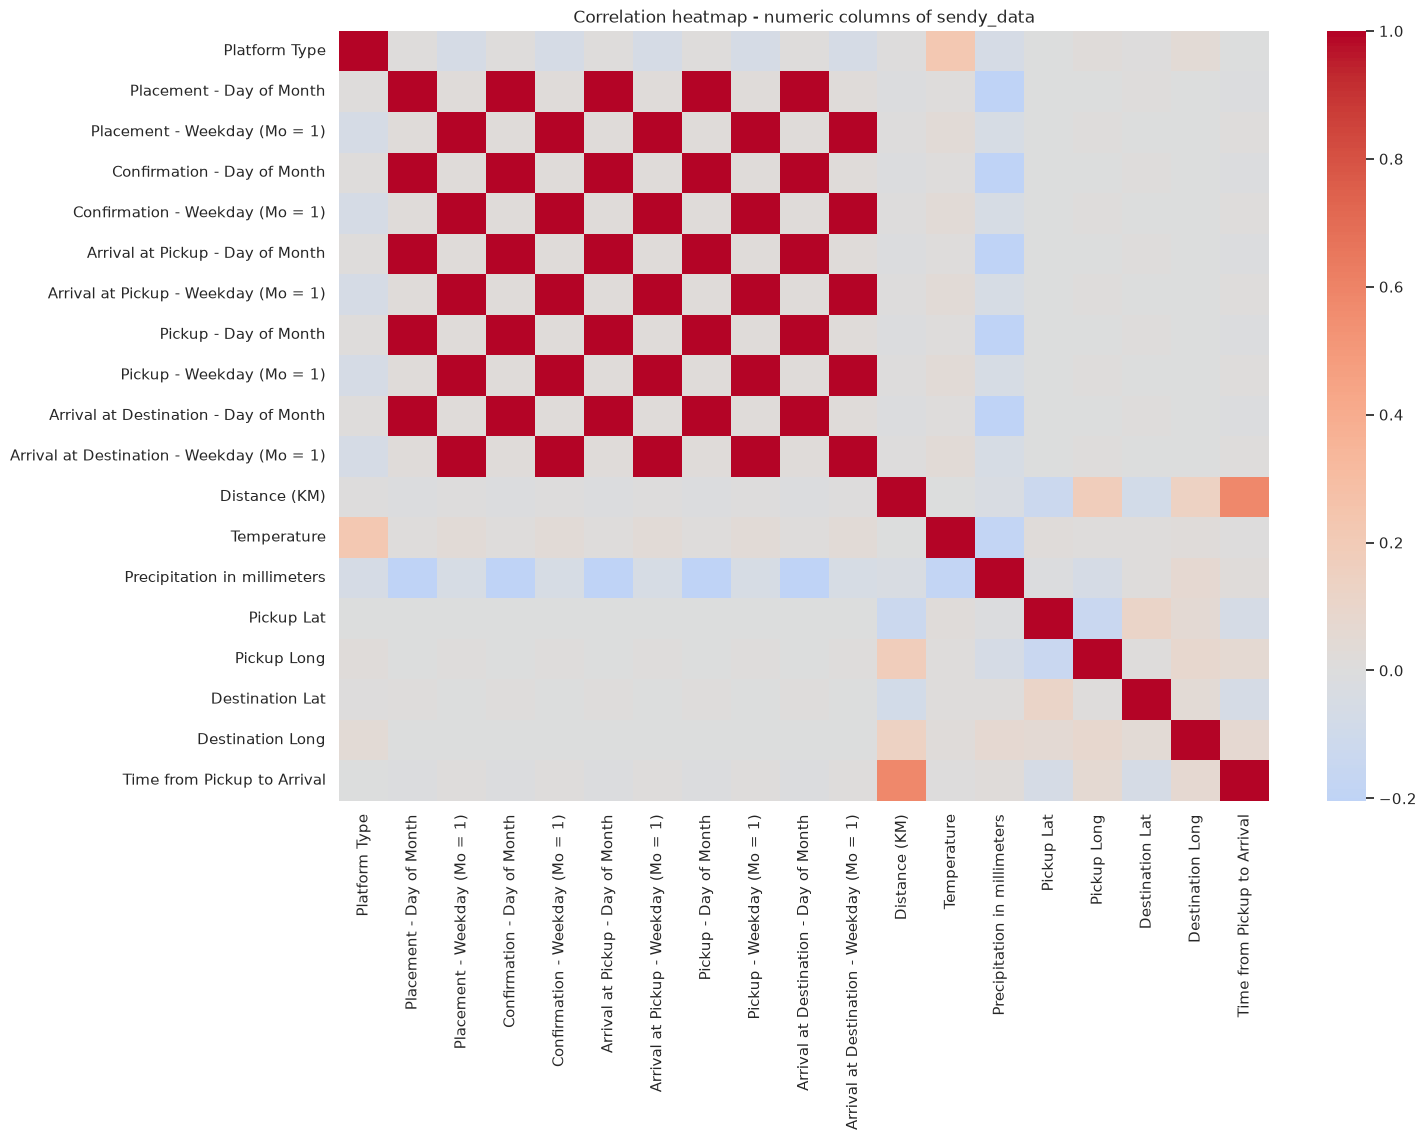

In [12]:
numeric_df = sendy_data.select_dtypes(include='number')
plt.figure(figsize=(15, 10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0)
plt.title('Correlation heatmap - numeric columns of sendy_data')
plt.show()

Most columns barely correlate with `Precipitation in millimeters` — unsurprising, since weather is largely independent of order logistics. `Destination Lat`, `Destination Long` and `Time from Pickup to Arrival` show the least-weak relationship, so we use those three to predict the missing rainfall values with a simple linear model.

In [13]:
from sklearn.linear_model import LinearRegression

to_train = ['Precipitation in millimeters', 'Destination Lat', 'Destination Long', 'Time from Pickup to Arrival']
temp_df = sendy_data[to_train]

# WHAT: rows where Precipitation is known become the training set; rows where
#       it's missing become the prediction set.
known = temp_df['Precipitation in millimeters'].notna()
x_train = temp_df.loc[known].drop(columns='Precipitation in millimeters')
y_train = temp_df.loc[known, 'Precipitation in millimeters']
x_missing = temp_df.loc[~known].drop(columns='Precipitation in millimeters')

lr = LinearRegression()
lr.fit(x_train, y_train)
predicted_precipitation = lr.predict(x_missing)

# WHY: .loc[mask, col] = ... assigns back into the real column safely;
#      chained indexing (df[col][mask] = ...) can silently fail to write.
sendy_data.loc[~known, 'Precipitation in millimeters'] = predicted_precipitation
np.round(predicted_precipitation[:10], 3)

array([ 8.031,  8.186,  7.861,  7.503,  7.725,  8.601,  8.95 ,  6.866,
        9.083, 11.095])

**⚡ Beyond the syllabus.** Doing this by hand (train/test split, fit, predict, write back) is worth understanding once — but scikit-learn has a purpose-built tool for exactly this: `IterativeImputer`. It repeatedly predicts each missing column from all the others (using any regressor you like) until the estimates stabilise. We apply it to `Temperature` below, so its predictions can be compared against the flat mean/mode/median computed earlier, for the *same* missing rows.

In [14]:
# explicitly required: IterativeImputer is still an experimental sklearn feature
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

to_impute = ['Temperature', 'Destination Lat', 'Destination Long', 'Time from Pickup to Arrival']
imputer = IterativeImputer(RandomForestRegressor(n_estimators=10, random_state=1), max_iter=5, random_state=1)
sendy_data[to_impute] = pd.DataFrame(
    imputer.fit_transform(sendy_data[to_impute]), columns=to_impute, index=sendy_data.index
)

comparison = pd.DataFrame({'IterativeImputer (actual fill)': sendy_data.loc[missing_temperature_idx, 'Temperature']})
comparison['flat mean (not used)'] = mean_df
comparison['flat median (not used)'] = median_df
comparison.head(10)

,IterativeImputer (actual fill),flat mean (not used),flat median (not used)
2,22.85,23,24
8,25.79,23,24
14,22.17,23,24
15,21.87,23,24
16,22.43,23,24
32,23.78,23,24
42,21.95,23,24
46,24.77,23,24
49,20.92,23,24
53,23.12,23,24


## 4 · Categorical features — manual ordinal maps & automated encoders

Models need numbers, not text, so every categorical column must be **encoded**. The right scheme depends on the category type:

- **Ordinal** categories have a natural order (star ratings, education level) — encode with an explicit map that preserves the order.
- **Non-ordinal** categories have no order (bank name, account type) — encode with one-hot, hashing, or another scheme from `03_encoding_masterclass.ipynb`'s full catalogue.

`level_of_education_clients` is ordinal (`Primary` < `Secondary` < `Graduate` < `Post-Graduate`), so we assign it an explicit integer map rather than an automated encoder, which would have no way to know the intended order.

In [15]:
loan_demographics['level_of_education_clients'].unique()

<StringArray>
[nan, 'Secondary', 'Graduate', 'Post-Graduate', 'Primary']
Length: 5, dtype: str

In [16]:
# WHAT: an explicit dict preserves the real-world ordering an automated
#       encoder can't infer on its own.
education_order = {'Primary': 1, 'Secondary': 2, 'Graduate': 3, 'Post-Graduate': 4}
loan_demographics['level_of_education_clients'] = (
    loan_demographics['level_of_education_clients'].map(education_order)
)
loan_demographics['level_of_education_clients'].value_counts()

level_of_education_clients
3.0    420
2.0     89
4.0     68
1.0     10
Name: count, dtype: int64

**Note:** ~86% of `level_of_education_clients` is missing (Section 2's mode/model-based techniques apply here too — mapping alone doesn't fill gaps, it only recodes the values that are present).

For the non-ordinal, higher-cardinality columns (`bank_name_clients`: 18 classes, `bank_branch_clients`: 45 classes), an automated encoder is more practical than a hand-written map. `category_encoders` (imported in the setup cell, with built-in equivalents if it isn't installed) offers several out of the box — see `03_encoding_masterclass.ipynb` for a deep dive into when to prefer each. Here we compare three, each fit on the **untouched original columns** — not on each other's already-encoded output, which would make hashing/one-hot encode meaningless integer codes instead of the real categories.

In [17]:
cat_cols = loan_demographics.select_dtypes(include='object').columns.drop(['customerid', 'birthdate'], errors='ignore')
for col in cat_cols:
    print(f"{col}: {loan_demographics[col].nunique()} classes")

bank_account_type: 3 classes
bank_name_clients: 18 classes
bank_branch_clients: 45 classes
employment_status_clients: 6 classes


In [18]:
# WHAT: OrdinalEncoder assigns each category an arbitrary integer code — what
#       most people mean by "label encoding" for a non-ordinal column.
# WHY:  compact (one column stays one column), at the cost of implying a
#       numeric order that isn't really there — fine for tree-based models,
#       riskier for linear/distance-based ones (see 03_encoding_masterclass.ipynb).
ordinal_cols = ['bank_name_clients', 'bank_branch_clients']
ordinal_encoded = ce.OrdinalEncoder(cols=ordinal_cols).fit_transform(loan_demographics[ordinal_cols])
ordinal_encoded.head()

,bank_name_clients,bank_branch_clients
0,7,NaN
1,13,NaN
2,5,NaN
3,7,NaN
4,7,NaN


In [19]:
# WHY: use employment_status_clients (non-ordinal, already imputed in Section 2)
#      rather than the education column, which we just deliberately gave an
#      ordinal map above — one-hot encoding it now would throw that order away.
onehot_cols = ['bank_account_type', 'employment_status_clients']
onehot_encoded = ce.OneHotEncoder(cols=onehot_cols, use_cat_names=True).fit_transform(loan_demographics[onehot_cols])
onehot_encoded.head()

,bank_account_type_Current,bank_account_type_Other,bank_account_type_Savings,employment_status_clients_Contract,employment_status_clients_Permanent,employment_status_clients_Retired,employment_status_clients_Self-Employed,employment_status_clients_Student,employment_status_clients_Unemployed
0,0,0,1,0,1,0,0,0,0
1,0,0,1,0,1,0,0,0,0
2,0,0,1,0,1,0,0,0,0
3,0,0,1,0,1,0,0,0,0
4,0,0,1,0,1,0,0,0,0


In [20]:
# WHY: hashing trades a (rare) collision for a column count that never grows -
#      here 18 and 45 real categories both collapse to a fixed 10 columns.
hash_cols = ['bank_name_clients', 'bank_branch_clients']
hash_encoded = ce.HashingEncoder(cols=hash_cols, n_components=10).fit_transform(loan_demographics[hash_cols])
hash_encoded.head()

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9
0,0,0,0,1,1,0,0,0,0,0
1,0,0,0,1,0,0,1,0,0,0
2,0,0,0,1,0,0,1,0,0,0
3,0,0,0,1,1,0,0,0,0,0
4,0,0,0,1,1,0,0,0,0,0


Each of these returns a new table of encoded columns — in a real pipeline you'd `pd.concat` the ones you choose back onto `loan_demographics` (and drop the original text columns), the same as `03_encoding_masterclass.ipynb`.

## 5 · Numerical feature engineering — log transforms & domain-knowledge features

Two broad techniques for numerical columns:

1. **Log transform** — compresses a right-skewed distribution so it's closer to normal, which helps many models (and is easy to reverse: exponentiate predictions back at the end if you log-transformed a target).
2. **Domain knowledge** — combine columns using what you know about the business or the physics, not a generic statistical rule.

`Distance (KM)` in `sendy_data` is right-skewed — a good candidate for a log transform.

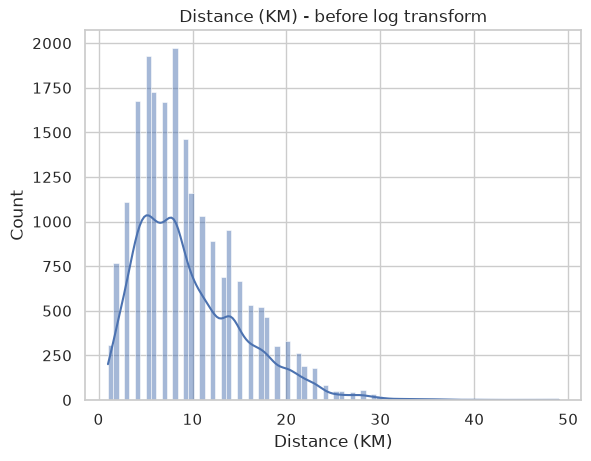

In [21]:
sns.histplot(sendy_data['Distance (KM)'], kde=True)
plt.title('Distance (KM) - before log transform')
plt.show()

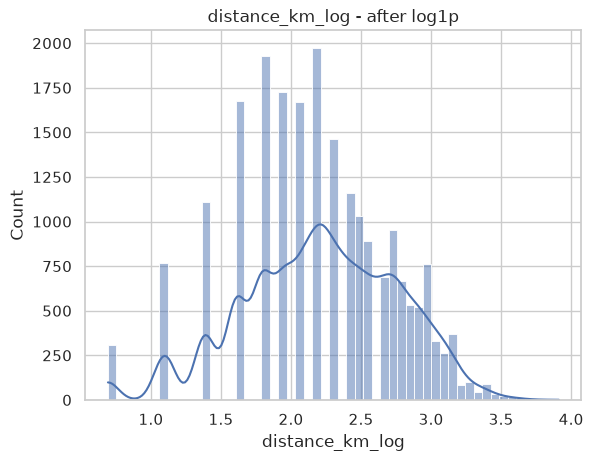

In [22]:
# WHY: keep the transform in a new column — Section 9 still needs the
#      original, untransformed Distance (KM) to compute a real speed feature.
sendy_data['distance_km_log'] = np.log1p(sendy_data['Distance (KM)'])

sns.histplot(sendy_data['distance_km_log'], kde=True)
plt.title('distance_km_log - after log1p')
plt.show()

`np.log1p` adds 1 before taking the log (`log(1+x)`), so a distance of zero doesn't blow up to `-inf`.

Now two domain-knowledge features from the loan data, using nothing more than arithmetic a domain expert would recognise immediately:

1. **Interest elapsed** — the gap between what was ultimately due and what was originally borrowed.
2. **Loan count** — how many times each customer has borrowed before, by aggregating `loan_previous`.

In [23]:
# WHAT: totaldue includes the loan's interest/fees; loanamount is the principal.
loan_previous['interest_elapsed'] = loan_previous['totaldue'] - loan_previous['loanamount']
loan_previous[['customerid', 'loanamount', 'totaldue', 'interest_elapsed']].head()

,customerid,loanamount,totaldue,interest_elapsed
0,8a2a81a74ce8c05d014cfb32a0da1049,10000.0,13000.0,3000.0
1,8a2a81a74ce8c05d014cfb32a0da1049,10000.0,13000.0,3000.0
2,8a2a81a74ce8c05d014cfb32a0da1049,20000.0,23800.0,3800.0
3,8a8588f35438fe12015444567666018e,10000.0,11500.0,1500.0
4,8a85890754145ace015429211b513e16,10000.0,11500.0,1500.0


In [24]:
# WHAT: count how many previous loans each customer took out, then attach
#       that per-customer count back onto every one of their rows.
loan_count = (
    loan_previous.groupby('customerid').agg(loan_count=('loannumber', 'count')).reset_index()
)
loan_previous = loan_previous.merge(loan_count, how='left', on='customerid')
loan_previous[['customerid', 'loan_count']].drop_duplicates().head()

,customerid,loan_count
0,8a2a81a74ce8c05d014cfb32a0da1049,11
3,8a8588f35438fe12015444567666018e,6
4,8a85890754145ace015429211b513e16,2
5,8a858970548359cc0154883481981866,8
7,8a8589f35451855401546b0738c42524,7


Finally, **speed** — distance per unit time — straight from physics, using the *untransformed* `Distance (KM)` and the delivery duration.

In [25]:
# WHY: convert seconds to hours so speed comes out in interpretable km/h,
#      rather than a tiny, hard-to-read km/second decimal.
sendy_data['speed_kmph'] = sendy_data['Distance (KM)'] / (sendy_data['Time from Pickup to Arrival'] / 3600)
sendy_data[['Distance (KM)', 'Time from Pickup to Arrival', 'speed_kmph']].head()

,Distance (KM),Time from Pickup to Arrival,speed_kmph
0,4,745.0,19.328859
1,16,1993.0,28.901154
2,3,455.0,23.736264
3,9,1341.0,24.161074
4,9,1214.0,26.688633


## 6 · Polynomial (interaction) features

Polynomial features capture *interactions* between columns — e.g. does the combined effect of loan amount and term length predict something that neither does alone? `sklearn`'s `PolynomialFeatures` generates every product/power combination up to a chosen degree automatically, so you don't have to hand-write each cross term.

In [26]:
from sklearn.preprocessing import PolynomialFeatures

to_cross = ['loannumber', 'totaldue', 'termdays']
poly = PolynomialFeatures(degree=2, include_bias=False)
crossed = poly.fit_transform(loan_previous[to_cross])
crossed = pd.DataFrame(crossed, columns=poly.get_feature_names_out(to_cross), index=loan_previous.index)

# WHY: drop the plain loannumber/totaldue/termdays columns PolynomialFeatures
#      also returns - they already exist in loan_previous, so keep only the
#      genuinely new squared/interaction terms.
loan_previous = pd.concat([loan_previous, crossed.drop(columns=to_cross)], axis=1)
loan_previous.head().T

,0,1,2,3,4
customerid,8a2a81a74ce8c05d014cfb32a0da1049,8a2a81a74ce8c05d014cfb32a0da1049,8a2a81a74ce8c05d014cfb32a0da1049,8a8588f35438fe12015444567666018e,8a85890754145ace015429211b513e16
systemloanid,301682320,301883808,301831714,301861541,301941754
loannumber,2,9,8,5,2
approveddate,2016-08-15 18:22:40.000000,2017-04-28 18:39:07.000000,2017-03-05 10:56:25.000000,2017-04-09 18:25:55.000000,2017-06-17 09:29:57.000000
creationdate,2016-08-15 17:22:32.000000,2017-04-28 17:38:53.000000,2017-03-05 09:56:19.000000,2017-04-09 17:25:42.000000,2017-06-17 08:29:50.000000
loanamount,10000.0,10000.0,20000.0,10000.0,10000.0
totaldue,13000.0,13000.0,23800.0,11500.0,11500.0
termdays,30,30,30,15,15
closeddate,2016-09-01 16:06:48.000000,2017-05-28 14:44:49.000000,2017-04-26 22:18:56.000000,2017-04-24 01:35:52.000000,2017-07-14 21:18:43.000000
referredby,NaN,NaN,NaN,NaN,NaN


## 7 · Normalization & scaling

Scaling puts numeric columns on a common range so no single feature dominates a distance-based model (KNN, k-means, linear/logistic regression, neural nets) purely because its raw numbers happen to be larger. Three common scalers:

| Scaler | What it does | Sensitive to outliers? |
|---|---|---|
| `StandardScaler` | Subtracts the mean, divides by the standard deviation | Yes |
| `RobustScaler` | Subtracts the median, divides by the IQR | No |
| `MinMaxScaler` | Rescales into a fixed range (e.g. 0-2) | Yes |

**Never fit a scaler on test/validation data** — fit on train only, then `.transform()` the rest, or information about the held-out set leaks into training. Scalers also aren't robust to missing values, so fill gaps before scaling.

In [27]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

scale_cols = ['loannumber', 'totaldue', 'termdays']
standard_scaled = StandardScaler().fit_transform(loan_previous[scale_cols])
robust_scaled   = RobustScaler().fit_transform(loan_previous[scale_cols])
minmax_scaled   = MinMaxScaler(feature_range=(0, 2)).fit_transform(loan_previous[scale_cols])

print("standard scaler ->", np.round(standard_scaled[:3, 0], 3))
print("robust scaler   ->", np.round(robust_scaled[:3, 0], 3))
print("minmax scaler   ->", np.round(minmax_scaled[:3, 0], 3))

standard scaler -> [-0.674  1.48   1.173]
robust scaler   -> [-0.25  1.5   1.25]
minmax scaler   -> [0.08 0.64 0.56]


In [28]:
# WHY: comparing the same column (loannumber) across scalers side by side
#      makes the practical difference concrete, rather than three disconnected
#      raw arrays.
pd.DataFrame({
    'loannumber (raw)': loan_previous['loannumber'].head().to_numpy(),
    'standard': standard_scaled[:5, 0],
    'robust': robust_scaled[:5, 0],
    'minmax_0_2': minmax_scaled[:5, 0],
})

,loannumber (raw),standard,robust,minmax_0_2
0,2,-0.673771,-0.25,0.08
1,9,1.480472,1.50,0.64
2,8,1.172723,1.25,0.56
3,5,0.249476,0.50,0.32
4,2,-0.673771,-0.25,0.08


## 8 · Date/time feature extraction

A single `datetime` column is a bundle of features waiting to be unbundled — see `01_feature_extraction_and_engineering.ipynb` Section 4 for the deep dive on cyclical encoding and recency. Here we extract two more patterns from `loan_performance`'s `creationdate`/`approveddate`: **elapsed time between two related dates**, and **calendar parts plus a manually-mapped period of day**.

In [29]:
loan_performance['approveddate'] = pd.to_datetime(loan_performance['approveddate'])
loan_performance['creationdate'] = pd.to_datetime(loan_performance['creationdate'])

# WHAT: elapsed time between two related date columns, in seconds.
loan_performance['approval_delay_secs'] = (
    (loan_performance['approveddate'] - loan_performance['creationdate']) / np.timedelta64(1, 's')
)
loan_performance[['creationdate', 'approveddate', 'approval_delay_secs']].head()

,creationdate,approveddate,approval_delay_secs
0,2017-07-25 07:22:47,2017-07-25 08:22:56,3609.0
1,2017-07-05 16:04:18,2017-07-05 17:04:41,3623.0
2,2017-07-06 13:52:51,2017-07-06 14:52:57,3606.0
3,2017-07-27 18:00:35,2017-07-27 19:00:41,3606.0
4,2017-07-03 22:42:39,2017-07-03 23:42:45,3606.0


In [30]:
# WHAT: pandas' .dt accessor pulls calendar parts straight out of a datetime column.
loan_performance['approved_day'] = loan_performance['approveddate'].dt.day
loan_performance['approved_week'] = loan_performance['approveddate'].dt.isocalendar().week
loan_performance['approved_hour'] = loan_performance['approveddate'].dt.hour
loan_performance[['approveddate', 'approved_day', 'approved_week', 'approved_hour']].head()

,approveddate,approved_day,approved_week,approved_hour
0,2017-07-25 08:22:56,25,30,8
1,2017-07-05 17:04:41,5,27,17
2,2017-07-06 14:52:57,6,27,14
3,2017-07-27 19:00:41,27,30,19
4,2017-07-03 23:42:45,3,27,23


In [31]:
# WHAT: a manual map from hour-of-day to a coarser period-of-day bucket.
# 🔧 CHANGE THIS: the hour boundaries are a judgement call - adjust them to
#      match whatever "morning/afternoon/evening" means for your data.
def period_of_day(hour):
    if hour <= 12:
        return 'morning'
    elif hour <= 16:
        return 'afternoon'
    else:
        return 'evening'

loan_performance['period_of_day'] = loan_performance['approved_hour'].map(period_of_day)
loan_performance['period_of_day'].value_counts()

period_of_day
morning      2022
evening      1218
afternoon    1128
Name: count, dtype: int64

## 9 · Geo features from latitude & longitude

Latitude/longitude pairs need their own feature-engineering techniques. Rather than reverse-geocoding every point into a physical address (slow, and often unnecessary), we can derive distances and directions directly from the coordinates — the formulations below are the well-known ones from [Beluga's "From EDA to the Top LB" Kaggle kernel](https://www.kaggle.com/gaborfodor/from-eda-to-the-top-lb-0-367).

In [32]:
def manhattan_distance(lat1, lng1, lat2, lng2):
    '''Sum of the horizontal and vertical distance between two points (in degrees).'''
    return np.abs(lat2 - lat1) + np.abs(lng1 - lng2)

sendy_data['distance_manhattan'] = manhattan_distance(
    sendy_data['Pickup Lat'], sendy_data['Pickup Long'],
    sendy_data['Destination Lat'], sendy_data['Destination Long'],
)
sendy_data[['Pickup Lat', 'Pickup Long', 'Destination Lat', 'Destination Long', 'distance_manhattan']].head()

,Pickup Lat,Pickup Long,Destination Lat,Destination Long,distance_manhattan
0,-1.317755,36.830370,-1.300406,36.829741,0.017978
1,-1.351453,36.899315,-1.295004,36.814358,0.141406
2,-1.308284,36.843419,-1.300921,36.828195,0.022588
3,-1.281301,36.832396,-1.257147,36.795063,0.061487
4,-1.266597,36.792118,-1.295041,36.809817,0.046142


In [33]:
def haversine_array(lat1, lng1, lat2, lng2):
    '''Great-circle distance between two points, in kilometers.'''
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    AVG_EARTH_RADIUS = 6371  # km
    lat, lng = lat2 - lat1, lng2 - lng1
    d = np.sin(lat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(lng / 2) ** 2
    return 2 * AVG_EARTH_RADIUS * np.arcsin(np.sqrt(d))

sendy_data['distance_haversine'] = haversine_array(
    sendy_data['Pickup Lat'], sendy_data['Pickup Long'],
    sendy_data['Destination Lat'], sendy_data['Destination Long'],
)
sendy_data[['distance_manhattan', 'distance_haversine']].head()

,distance_manhattan,distance_haversine
0,0.017978,1.930333
1,0.141406,11.339849
2,0.022588,1.880079
3,0.061487,4.943458
4,0.046142,3.724829


In [34]:
def bearing_array(lat1, lng1, lat2, lng2):
    '''Compass direction (0-360 deg) to travel from point 1 to point 2.'''
    lng_delta_rad = np.radians(lng2 - lng1)
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    y = np.sin(lng_delta_rad) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(lng_delta_rad)
    return np.degrees(np.arctan2(y, x)) % 360  # wrap into the conventional 0-360 deg range

sendy_data['bearing'] = bearing_array(
    sendy_data['Pickup Lat'], sendy_data['Pickup Long'],
    sendy_data['Destination Lat'], sendy_data['Destination Long'],
)
sendy_data[['bearing']].describe()

,bearing
count,21201.000000
mean,186.446821
std,100.937788
min,0.046805
25%,105.740018
50%,177.923111
75%,278.123547
max,359.971790


In [35]:
# WHAT: the midpoint between pickup and destination - useful as a single
#       representative location for e.g. clustering deliveries by area.
sendy_data['center_latitude'] = (sendy_data['Pickup Lat'] + sendy_data['Destination Lat']) / 2
sendy_data['center_longitude'] = (sendy_data['Pickup Long'] + sendy_data['Destination Long']) / 2
sendy_data[['center_latitude', 'center_longitude']].head()

,center_latitude,center_longitude
0,-1.309080,36.830056
1,-1.323229,36.856837
2,-1.304603,36.835807
3,-1.269224,36.813730
4,-1.280819,36.800968


### Recap

- **Imputed** missing categorical values by mode, and missing numerical values three ways — flat statistic, hand-rolled regression fill, and `IterativeImputer` — comparing the last two on the same column.
- **Encoded** categorical features by explicit ordinal map (when order is real) and by automated ordinal/one-hot/hashing encoders (when it isn't), each demonstrated on the untouched original columns so the comparison is fair.
- **Engineered** numerical features from domain knowledge — interest elapsed, per-customer loan counts, real-unit speed — without letting an earlier log transform silently corrupt a later feature.
- **Built** polynomial interaction features and compared three scalers side by side on the same column.
- **Extracted** elapsed time, calendar parts and a manual period-of-day bucket from raw date strings.
- **Derived** Manhattan distance, Haversine distance, bearing and a center point purely from latitude/longitude pairs.

**Where this feeds next:** the encoded, scaled, feature-rich tables here are the right input for `06_Statistics_and_Regression/` and `07_Model_Preparation/` — this notebook stops short of an actual train/test split and model fit, since the goal here was breadth of technique across real, messy data, not a single end-to-end pipeline (see `04_sales_case_study_full_pipeline.ipynb` and `05_student_case_study_full_pipeline.ipynb` for that shape instead).

---

## Exam quick-reference

| To do this | Write this |
|---|---|
| Fill categorical NAs with the mode | `s.fillna(s.mode()[0])` |
| Fill numerical NAs with mean/median | `s.fillna(s.mean())` / `s.fillna(s.median())` |
| Model-based fill (manual) | Split rows by `.notna()`, fit on the known rows, `.predict()` the missing ones |
| Model-based fill (automatic) | `IterativeImputer(estimator).fit_transform(df[cols])` |
| Ordinal map (order matters) | `s.map({'Low': 1, 'High': 2})` |
| Ordinal/label encode (order doesn't matter) | `ce.OrdinalEncoder(cols=[...]).fit_transform(df)` |
| One-hot encode | `ce.OneHotEncoder(cols=[...], use_cat_names=True).fit_transform(df)` |
| Hash encode (fixed column count) | `ce.HashingEncoder(cols=[...], n_components=k).fit_transform(df)` |
| Log-transform a skewed column | `np.log1p(s)` |
| Groupby aggregate, then merge back | `df.groupby('key').agg(new=('col','count')).reset_index()`, then `df.merge(..., how='left', on='key')` |
| Polynomial/interaction features | `PolynomialFeatures(degree=2).fit_transform(df[cols])` |
| Standardize / robust-scale / min-max scale | `StandardScaler()` / `RobustScaler()` / `MinMaxScaler()` |
| Elapsed time between two dates | `(a - b) / np.timedelta64(1, 's')` |
| Haversine distance | see `haversine_array()` above |

### Adapting this in the exam

- 'Fill in the missing values sensibly' → categorical → mode; numerical → mean/median, or a model-based fill if you can justify which columns predict it.
- 'This column has too many categories for one-hot' → hashing or ordinal/label encoding, not one-hot.
- 'Create an interaction feature between X and Y' → `PolynomialFeatures` if you want every combination automatically, or just `df['X'] * df['Y']` if you only need the one term.
- 'Scale the features before fitting a distance-based model' → fit the scaler on train only, `.transform()` everything else.
- Given two latitude/longitude pairs and asked for "the distance" → Haversine is the physically correct one; Manhattan is the cheap approximation.

### Traps that cost marks

- Filling categorical NAs with the *median* (or numerical NAs with the *mode*) — match the fill strategy to the column type.
- Fitting a scaler (or an imputer) on the full dataset instead of train-only — a classic, easy-to-miss leakage bug.
- Reusing a column you've already transformed (e.g. log-transforming `Distance (KM)` in place) for a later feature that needed the original units — keep transforms in a new column unless you're sure nothing downstream needs the original.
- One-hot encoding a column you've already ordinal-mapped — you'll one-hot the integer codes, not the original categories, and lose the very order you just encoded.
- `PolynomialFeatures` returns the original columns too (degree-1 terms) — concatenating its full output back onto your DataFrame duplicates them under generic names unless you drop or rename first.
- Manhattan distance on raw lat/long degrees is not in kilometers — it's only useful as a relative/comparative measure, not an absolute one. Haversine gives you real kilometers.